In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utils.helpers.plotting_helper import set_plotting_defaults
from utils.profile_slab import OrientationProfile

set_plotting_defaults()

In [19]:
model_path = Path.cwd().parent.parent / "models/fitting_results"
model_path.exists()

True

In [20]:
import pickle as pkl
from pyref.fitting import GlobalObjective

model_paths = model_path.rglob("*.pkl")
models: dict[str, GlobalObjective] = {}
for p in model_paths:
    with p.open("rb") as f:
        mod = pkl.load(f)
        if isinstance(mod, dict):
            continue
        models[p.stem] = mod

for m, o in models.items():
    print(f"{m}: {type(o)}")

fitting_results_free_model: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_free_model_2: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_fixed_3: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_profile_3: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_fixed: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_fixed_2: <class 'refnx.analysis.objective.GlobalObjective'>
fitting_results_profile_free: <class 'refnx.analysis.objective.GlobalObjective'>


fitting_results_free_model
fitting_results_free_model_2
fitting_results_fixed_3
fitting_results_profile_3
fitting_results_fixed
fitting_results_fixed_2
fitting_results_profile_free


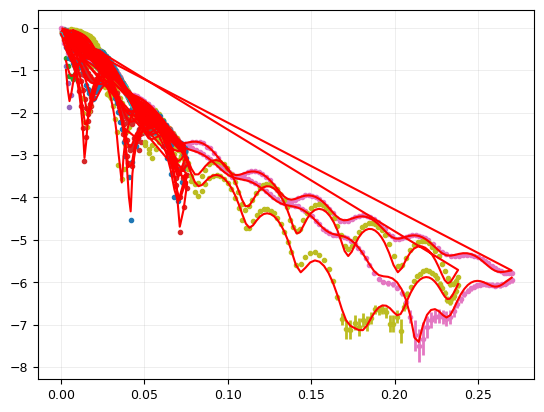

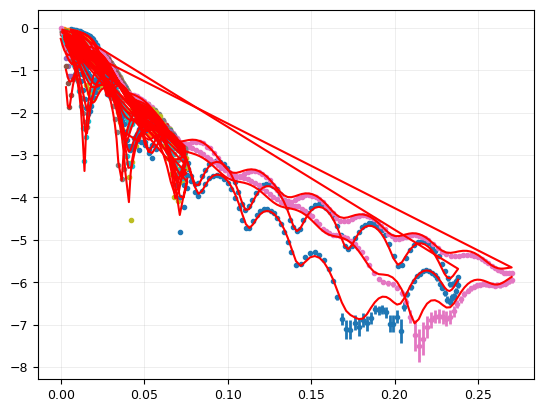

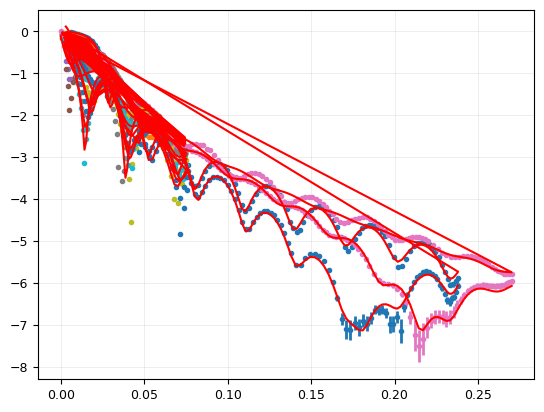

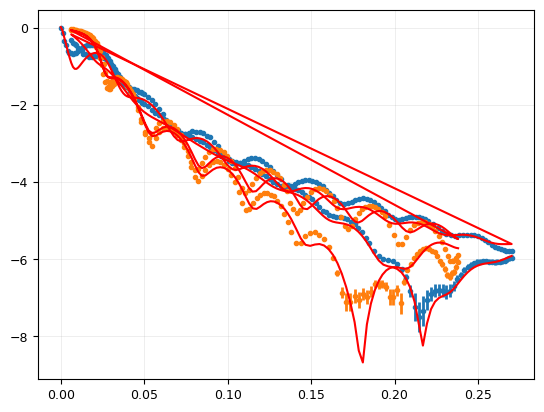

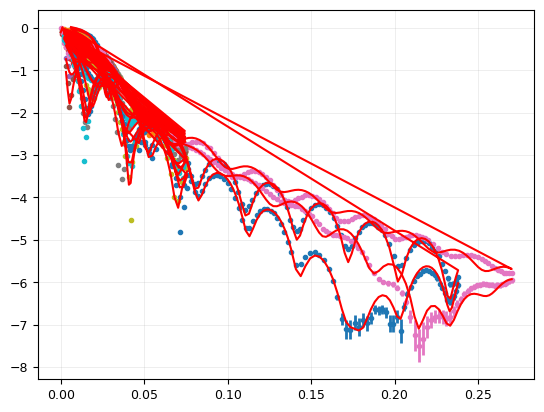

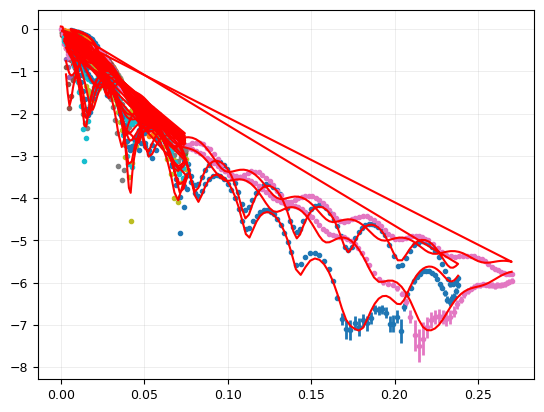

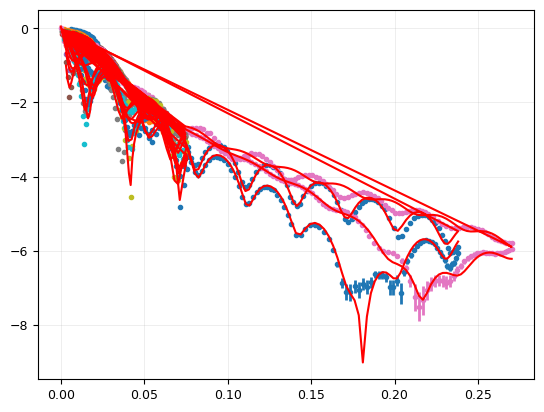

In [21]:
from utils.helpers.fitting_helper import bic, aic, reduced_chi2, ObjectiveInterface

df_builder = []

for n, o in models.items():
    print(n)
    fig, *_ = o.plot()
    # grab the axes out of this figure and add some stats to each plot
    # axs = fig.get_axes()[0]
    df_builder.append({
        "model": n,
        "nparams": ObjectiveInterface(o).nparams(),
        "ndata": ObjectiveInterface(o).ndata(),
        "chi2": o.chisqr(),
        "logl": o.logl(),
        "nll": o.nll(),
        "logp": o.logp(),
        "bic": bic(o),
        "aic": aic(o),
        "rmsd": reduced_chi2(o)
        })
    # # add the stats to the plot as a text box
    # axs.text(0.05, 0.95, "\n".join(stats), transform=axs.transAxes, fontsize=12,
    #     verticalalignment="top",
    # )
    # plt.show()

df = pd.DataFrame(df_builder)
df.to_csv("model_stats.csv", index=False)

In [22]:
for k, g in df.groupby("nparams"):
    display(g.sort_values("bic"))

,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
3,fitting_results_profile_3,31,555,14022.87692,-2873.273376,2873.273376,-19.186409,14218.764932,14084.87692,26.761215


,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
2,fitting_results_fixed_3,100,2766,48976.534262,-8932.484301,8932.484301,-37.821832,49769.050013,49176.534262,18.370793


,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
5,fitting_results_fixed_2,101,2766,18480.323679,-1296.130632,1296.130632,-37.821832,19280.764587,18682.323679,6.934455
4,fitting_results_fixed,101,2766,19969.028695,-1667.082832,1667.082832,-27.908765,20769.469603,20171.028695,7.493069


,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
6,fitting_results_profile_free,240,2766,22781.933298,-2372.905719,2372.905719,-15.613218,24683.971101,23261.933298,9.018976


,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
0,fitting_results_free_model,327,2766,6601.102241,2824.245133,-2824.245133,2185.816976,9192.628748,7255.102241,2.706479


,model,nparams,ndata,chi2,logl,nll,logp,bic,aic,rmsd
1,fitting_results_free_model_2,370,2766,22444.552155,-2286.56362,2286.56362,2307.417049,25376.860434,23184.552155,9.367509


In [ ]:
# tags to care about
# fitting_results_fixed_3, and fitting_results_fixed
obj_fixed_3 = models["fitting_results_fixed_3"]
obj_fixed_2 = models["fitting_results_fixed_2"]

def params(obj):
    for p in obj.varying_parameters():
        # don't print scale_, or theta_
        n = p.name
        if not n.startswith("scale_") and not n.startswith("theta_"):
            print(p)

params(obj_fixed_3)
print(" "*100)
print("="*100)
print(" "*100)
params(obj_fixed_2)


<Parameter:'Surface_283.7_thick', value=10.0535 +/- 0.771, bounds=[0.0, 35.0]>
<Parameter:'Surface_283.7_rough', value=7.59891 +/- 0.468, bounds=[0.0, 25.0]>
<Parameter:'Surface_283.7_density', value=1.02524 +/- 0.0788, bounds=[1.0, 1.8]>
<Parameter:'Surface_283.7_rotation', value=1.39771 +/- 0.0404, bounds=[0.0, 1.5707963267948966]>
<Parameter:'ZnPc_283.7_thick', value=184.986 +/- 0.752, bounds=[160.0, 200.0]>
<Parameter:'ZnPc_283.7_rough', value=1.01666 +/- 1.38 , bounds=[0.0, 25.0]>
<Parameter:'ZnPc_283.7_density', value=1.67708 +/- 0.00482, bounds=[1.2, 1.8]>
<Parameter:'ZnPc_283.7_rotation', value=1.09527 +/- 0.00111, bounds=[0.0, 1.5707963267948966]>
<Parameter:'Contamination_283.7_thick', value=15.6404 +/- 0.773, bounds=[0.0, 35.0]>
<Parameter:'Contamination_283.7_rough', value=8.94016 +/- 0.516, bounds=[0.0, 25.0]>
<Parameter:'Contamination_283.7_density', value=1.75013 +/- 0.0179, bounds=[1.0, 1.8]>
<Parameter:'Contamination_283.7_rotation', value=0.630826 +/- 0.0253, bounds=[

In [48]:
params(models["fitting_results_free_model_2"])

<Parameter:'Surface_250.0_diso', value=0.00276124 +/- 3.78e-05, bounds=[0.0026981256710032673, 0.002802600686772467]>
<Parameter:'Surface_250.0_biso', value=0.000564338 +/- 0.000181, bounds=[0.00017729699841652618, 0.0007091879936661047]>
<Parameter:'Surface_250.0_bire', value=-2.40157e-05 +/- 1.92e-05, bounds=[-5.2237507884599944e-05, 0.0]>
<Parameter:'ZnPc_250.0_density', value=1.55128 +/- 0.0627, bounds=[1.2, 1.8]>
<Parameter:'Contamination_250.0_diso', value=0.00337772 +/- 1.57e-05, bounds=[0.0033569717516984936, 0.0033992086684357485]>
<Parameter:'Contamination_250.0_biso', value=0.000384369 +/- 0.000192, bounds=[0.00021776224290034793, 0.0008710489716013917]>
<Parameter:'Contamination_250.0_bire', value=-1.11053e-05 +/- 7.92e-06, bounds=[-2.1118458368627434e-05, 0.0]>
<Parameter:'Oxide_250.0_rho', value=2.1996 +/- 0.0892, bounds=[2.1, 2.648]>
<Parameter:'Substrate_250.0_rho', value=2.36231 +/- 0.0252, bounds=[2.33, 2.4]>
<Parameter:'Surface_275.0_diso', value=0.0015072 +/- 0.0002

In [57]:
name_map = {
    "fitting_results_fixed_3": "dft_no_en_offset",
    "fitting_results_fixed_2": "dft_en_offset_best",
    "fitting_results_fixed": "dft_en_offset_init",
    "fitting_results_profile_3": "orient_profile_two_energies(bugged)",
    "fitting_results_profile_free": "orient_profile_all_energies(unconstrained)",
    "fitting_results_free_model": "free_en_offset_best",
    "fitting_results_free_model_2": "free_en_offset_init_2"
}

# apply the name map to the models and then save them in the same
# directory with the new names
for old_name, new_name in name_map.items():
    models[new_name] = models[old_name]
    del models[old_name]

for k, v in models.items():
    pth = model_path / f"{k}.pkl"
    with pth.open("wb") as f:
        pkl.dump(v, f)
